In [1]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import gensim
import gensim.corpora as corpora
from gensim.models import LsiModel
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("news_articles.csv")
data.info()
content = data['content'].str.lower().apply(lambda x: re.sub(r"([^\w\s])", '', x)) #convert to lower case and removing punctuation
en_stopwords = stopwords.words('english')
content = content.apply(lambda x: ' '.join (word for word in x.split() if word not in en_stopwords)) #removing stop words
content = content.apply(lambda x: word_tokenize(x)) #tokenizing
ps = PorterStemmer()
content = content.apply(lambda tokens: [ps.stem(token) for token in tokens])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       100 non-null    int64 
 1   title    100 non-null    object
 2   content  100 non-null    object
dtypes: int64(1), object(2)
memory usage: 2.5+ KB


In [3]:
#cleaning up the data
dictionary = corpora.Dictionary(content)
print(dictionary)
# vectorize using bag of words into a document term matrix
doc_term = [dictionary.doc2bow(text) for text in content]
# specify number of topics
num_topics = 2
# create LDA model
lda_model = gensim.models.LdaModel(corpus=doc_term,
                                   id2word=dictionary,
                                   num_topics=num_topics)
lda_model.print_topics(num_topics=num_topics, num_words=5)

Dictionary<8693 unique tokens: ['10', '100', '108', '15', '155']...>


[(0,
  '0.020*"mr" + 0.012*"said" + 0.006*"trump" + 0.004*"state" + 0.004*"year"'),
 (1,
  '0.017*"said" + 0.014*"mr" + 0.005*"trump" + 0.005*"would" + 0.004*"one"')]

In [4]:
lsimodel = LsiModel(doc_term, num_topics=num_topics, id2word=dictionary)
lsimodel.print_topics(num_topics=num_topics, num_words=5)

[(0,
  '0.615*"mr" + 0.429*"said" + 0.187*"trump" + 0.130*"state" + 0.119*"would"'),
 (1,
  '-0.537*"mr" + -0.319*"trump" + 0.286*"said" + 0.242*"saudi" + 0.142*"weight"')]

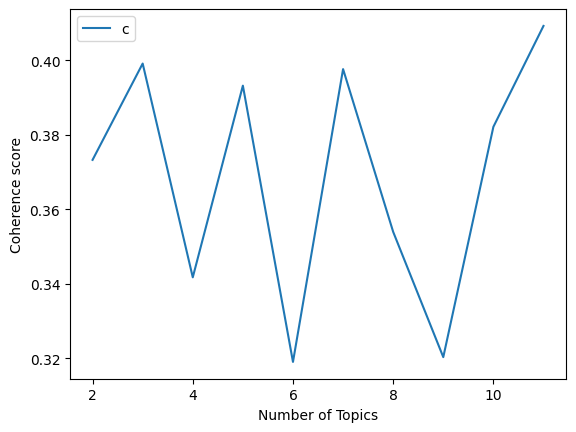

In [5]:
#coherence
coherence_values = []
model_list = []

min_topics =2
max_topics =11

for num_topics_i in range(min_topics, max_topics+1):
    model = LsiModel(doc_term, num_topics=num_topics_i, id2word = dictionary, random_seed=0)
    model_list.append(model)
    coherence_model = CoherenceModel(model=model, texts=content, dictionary=dictionary, coherence='c_v')
    coherence_values.append(coherence_model.get_coherence())

plt.plot(range(min_topics, max_topics+1), coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.show()

In [8]:
final_topics = 3
lsaModel = LsiModel(doc_term, num_topics=final_topics, id2word=dictionary)
print(lsaModel.print_topics(num_topics=final_topics, num_words=2))

[(0, '0.615*"mr" + 0.429*"said"'), (1, '-0.537*"mr" + -0.319*"trump"'), (2, '-0.460*"saudi" + -0.264*"taliban"')]
